# Explainability: Burnout Risk Prediction (Classification)

In [11]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler, LabelEncoder
from pytorch_tabnet.tab_model import TabNetClassifier
warnings.filterwarnings('ignore')
shap.initjs()

# 1. Load Data
df = pd.read_csv('data/developer_burnout_dataset_7000.csv')
df.dropna(subset=['stress_level', 'burnout_level'], inplace=True)
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)
    
X = df.drop(columns=['stress_level', 'burnout_level'])
le = LabelEncoder()
y = le.fit_transform(df['burnout_level'])
feature_names = X.columns

# 2. Preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

## 1. Random Forest Classifier

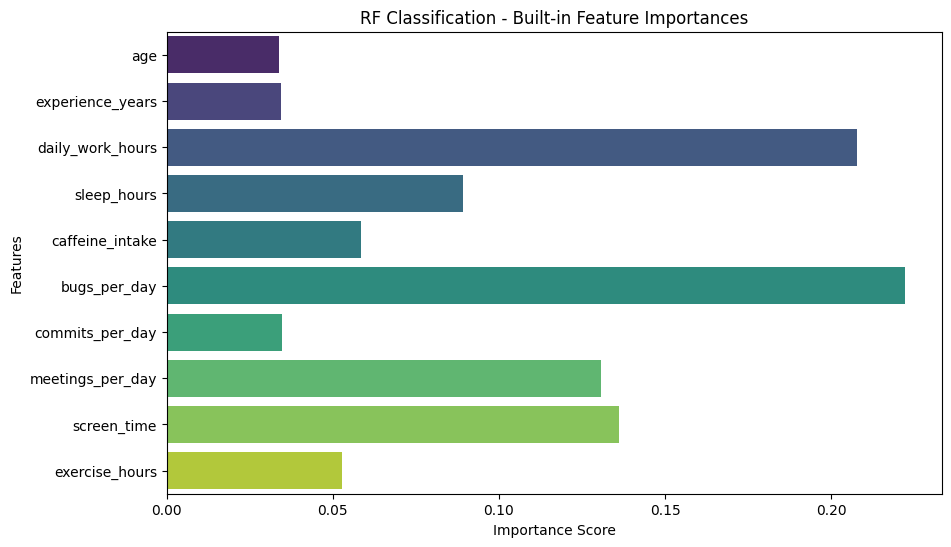

In [12]:
rf_c_model = joblib.load('random_forest/random_forest_classifier_optimized.pkl')

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_c_model.feature_importances_, y=feature_names, palette="viridis")
plt.title("RF Classification - Built-in Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

## 2. Support Vector Classifier (SVC)

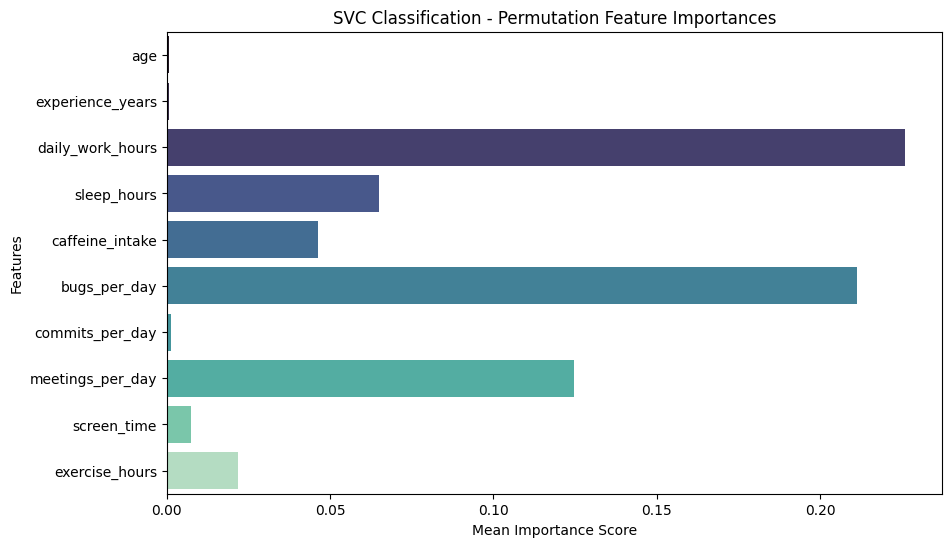

Calculating SHAP values for SVC... (This may take a moment)


100%|██████████| 200/200 [10:19<00:00,  3.10s/it]


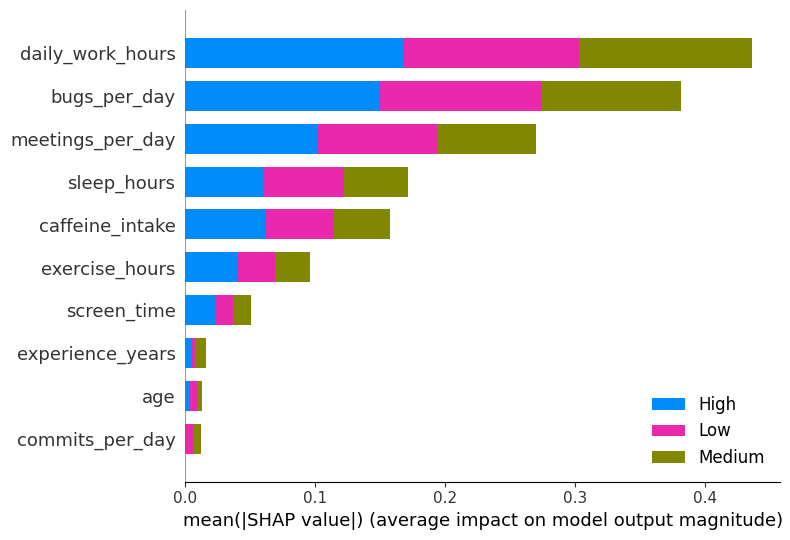

In [17]:
from sklearn.inspection import permutation_importance

svc_model = joblib.load('SVM/svc_burnout_model_optimized.pkl')

# 1. Feature Importances (Permutation method for SVM)
result_svc = permutation_importance(svc_model, X_scaled_df, y, n_repeats=5, random_state=42)
plt.figure(figsize=(10, 6))
sns.barplot(x=result_svc.importances_mean, y=feature_names, palette="mako")
plt.title("SVC Classification - Permutation Feature Importances")
plt.xlabel("Mean Importance Score")
plt.ylabel("Features")
plt.show()

# 2. SHAP Values (SVC)
print("Calculating SHAP values for SVC... (This may take a moment)")
X_sample_c = shap.sample(X_scaled_df, 50)
explainer_svc = shap.KernelExplainer(svc_model.predict_proba, X_sample_c)
shap_values_svc = explainer_svc.shap_values(X_scaled_df.iloc[:200])

# Stacked Bar Plot per class
shap.summary_plot(shap_values_svc, X_scaled_df.iloc[:200], class_names=le.classes_, plot_type="bar")

## 3. TabNet Classifier

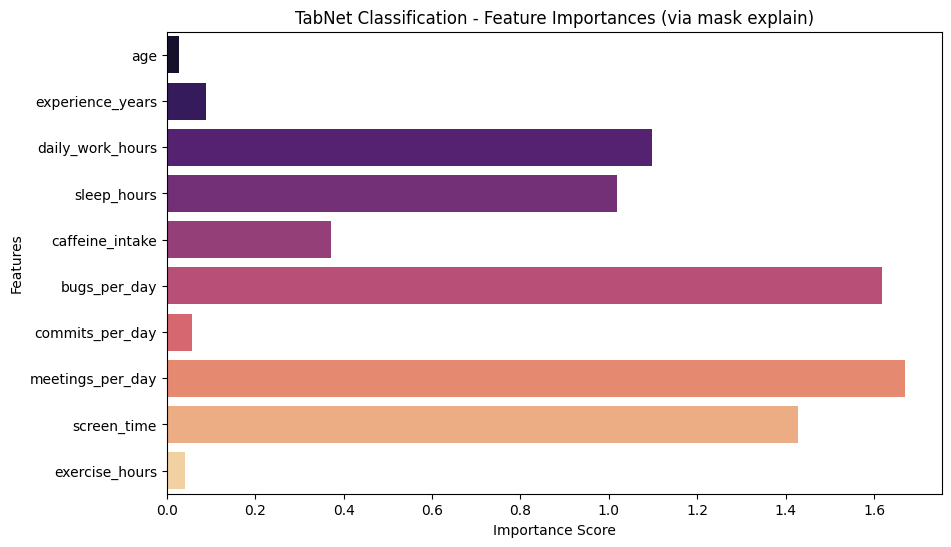

In [14]:
tabnet_c_model = TabNetClassifier()
tabnet_c_model.load_model('TabNet/tabnet_burnout_model_optimized.zip')

explain_matrix, masks = tabnet_c_model.explain(X_scaled_df.values.astype(np.float32))
feature_importances = explain_matrix.mean(axis=0)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_names, palette="magma")
plt.title("TabNet Classification - Feature Importances (via mask explain)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

## 4. KMeans Clustering

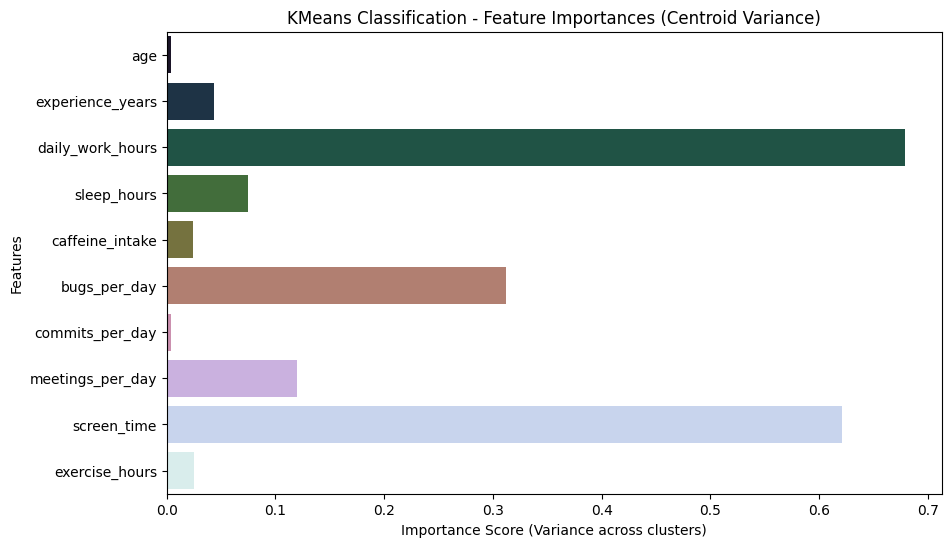

In [18]:
kmeans_model = joblib.load('kmeans/kmeans_burnout_model.pkl')
kmeans_scaler = joblib.load('kmeans/kmeans_burnout_scaler.pkl')

# For KMeans, "Feature Importance" can be interpreted as the variance of the centroids 
# across the clusters for each feature. A high variance means the feature strongly 
# differentiates the clusters.
centroid_variances = np.var(kmeans_model.cluster_centers_, axis=0)

plt.figure(figsize=(10, 6))
sns.barplot(x=centroid_variances, y=feature_names, palette="cubehelix")
plt.title("KMeans Classification - Feature Importances (Centroid Variance)")
plt.xlabel("Importance Score (Variance across clusters)")
plt.ylabel("Features")
plt.show()